# IMPORTS

In [1]:
from utils import read_and_clean_data, plot_data, generate_windowed_data

# Parameters

In [9]:
input_days=30
output_days=7
selected_price_column = "AMZN"
test_size=0.2
shuffle=True

# 

# Load dataset

In [2]:
amazon_data = read_and_clean_data(file_path="../dataset/portfolio_data.csv", drop_list=["DPZ", "BTC", "NFLX"])

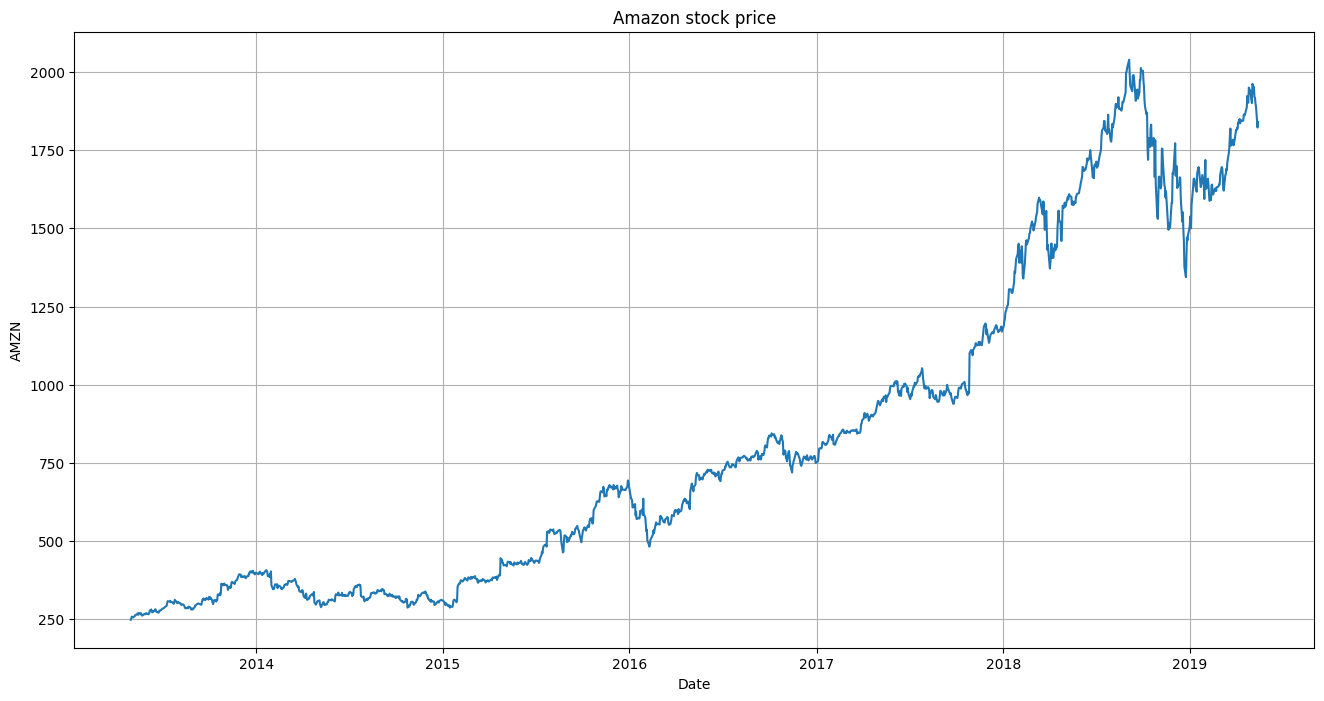

In [3]:
plot_data(amazon_data, "Amazon stock price", "Date", "AMZN")

In [4]:
amazon_price = amazon_data[selected_price_column].values

X, y = generate_windowed_data(amazon_price, input_days=input_days, output_days=output_days)

Expected generated data length should be: 1484
x_start_index: 0 - x_end_index: 29 | y_start_index: 30 - y_end_index 37
x_start_index: 1 - x_end_index: 30 | y_start_index: 31 - y_end_index 38
x_start_index: 2 - x_end_index: 31 | y_start_index: 32 - y_end_index 39
x_start_index: 3 - x_end_index: 32 | y_start_index: 33 - y_end_index 40
x_start_index: 4 - x_end_index: 33 | y_start_index: 34 - y_end_index 41
x_start_index: 5 - x_end_index: 34 | y_start_index: 35 - y_end_index 42
x_start_index: 6 - x_end_index: 35 | y_start_index: 36 - y_end_index 43
x_start_index: 7 - x_end_index: 36 | y_start_index: 37 - y_end_index 44
x_start_index: 8 - x_end_index: 37 | y_start_index: 38 - y_end_index 45


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, shuffle=shuffle)

In [6]:
from sklearn.preprocessing import MinMaxScaler

feature_scaler = MinMaxScaler()
X_train_norm = feature_scaler.fit_transform(X_train)
X_test_norm = feature_scaler.transform(X_test)

target_scaler = MinMaxScaler()
y_train_norm = target_scaler.fit_transform(y_train)
y_test_norm = target_scaler.transform(y_test)

In [7]:
print(f"Input Days: {input_days} - Output Days: {output_days}")
print(f"X_train Shape: {X_train_norm.shape} - X_test Shape: {X_test_norm.shape}")
print(f"y_train Shape: {y_train_norm.shape} - y_test Shape: {y_test_norm.shape}")

Input Days: 30 - Output Days: 7
X_train Shape: (1187, 30) - X_test Shape: (297, 30)
y_train Shape: (1187, 7) - y_test Shape: (297, 7)


# model